# Principal Component Analysis (PCA) on the Iris Dataset

## Overview
This notebook implements **Principal Component Analysis (PCA)** from scratch (using NumPy's eigen-decomposition) and via scikit-learn to reduce the Iris dataset from 4 dimensions to 2, enabling clear visual separation of the three flower species.

**Dataset:** Iris, the classic benchmark for multivariate analysis
- **Samples:** 150 (50 per class)
- **Features (4):** Sepal Length, Sepal Width, Petal Length, Petal Width
- **Classes (3):** Setosa, Versicolor, Virginica

**Goal:** Demonstrate that PCA can compress 4 features into 2 principal components while retaining >95% of the original variance, enabling clean 2D visualization of species clusters.

---

**Outline:**
1. Load & Explore the Dataset
2. Visualize Raw Features
3. Standardize the Data
4. Full PCA: Scree Plot & Explained Variance
5. Select 2 Components & Project
6. 2D Visualization
7. Biplot: Feature Loadings
8. Loadings Heatmap
9. Reconstruction & Error Analysis
10. Conclusion

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Plot 
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0f0',
    'xtick.color':      '#a0a0c0',
    'ytick.color':      '#a0a0c0',
    'text.color':       '#e0e0f0',
    'grid.color':       '#2a2a4a',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

# Colour palette for the 3 species
SPECIES_COLORS = ['#7dd3fc', '#f9a8d4', '#86efac']   # sky-blue, pink, green
SPECIES_NAMES  = ['Setosa', 'Versicolor', 'Virginica']

## 1. Load & Explore the Dataset

In [2]:
# Load Iris
iris = load_iris()
X = iris.data          # shape (150, 4)
y = iris.target        # 0, 1, 2

print('── Iris Dataset ──────────────────────────────')
print(f'Shape        : {X.shape}  (samples × features)')
print(f'Feature names: {iris.feature_names}')
print(f'Target names : {list(iris.target_names)}')
print()

# Class distribution
print('Class distribution:')
for i, name in enumerate(iris.target_names):
    count = (y == i).sum()
    print(f'  {name:12s}: {count} samples')
print()

# Summary statistics
df = pd.DataFrame(X, columns=['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width'])
df['Species'] = pd.Categorical.from_codes(y, iris.target_names)

print('Feature statistics (all classes):')
print(df.describe().round(3).to_string())

── Iris Dataset ──────────────────────────────
Shape        : (150, 4)  (samples × features)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Class distribution:
  setosa      : 50 samples
  versicolor  : 50 samples
  virginica   : 50 samples

Feature statistics (all classes):
       Sepal Length  Sepal Width  Petal Length  Petal Width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100        1.800
max           7.900        4.400         6.900        2.500


## 2. Visualize Raw Features

With 4 features it is impossible to visualize all dimensions at once. A **pair plot** shows every pairwise 2D projection, but each subplot uses only 2 of the 4 features, and there is no single view that captures the full structure.

This is exactly the problem PCA solves: it finds the *single best* 2D projection that retains the maximum variance.

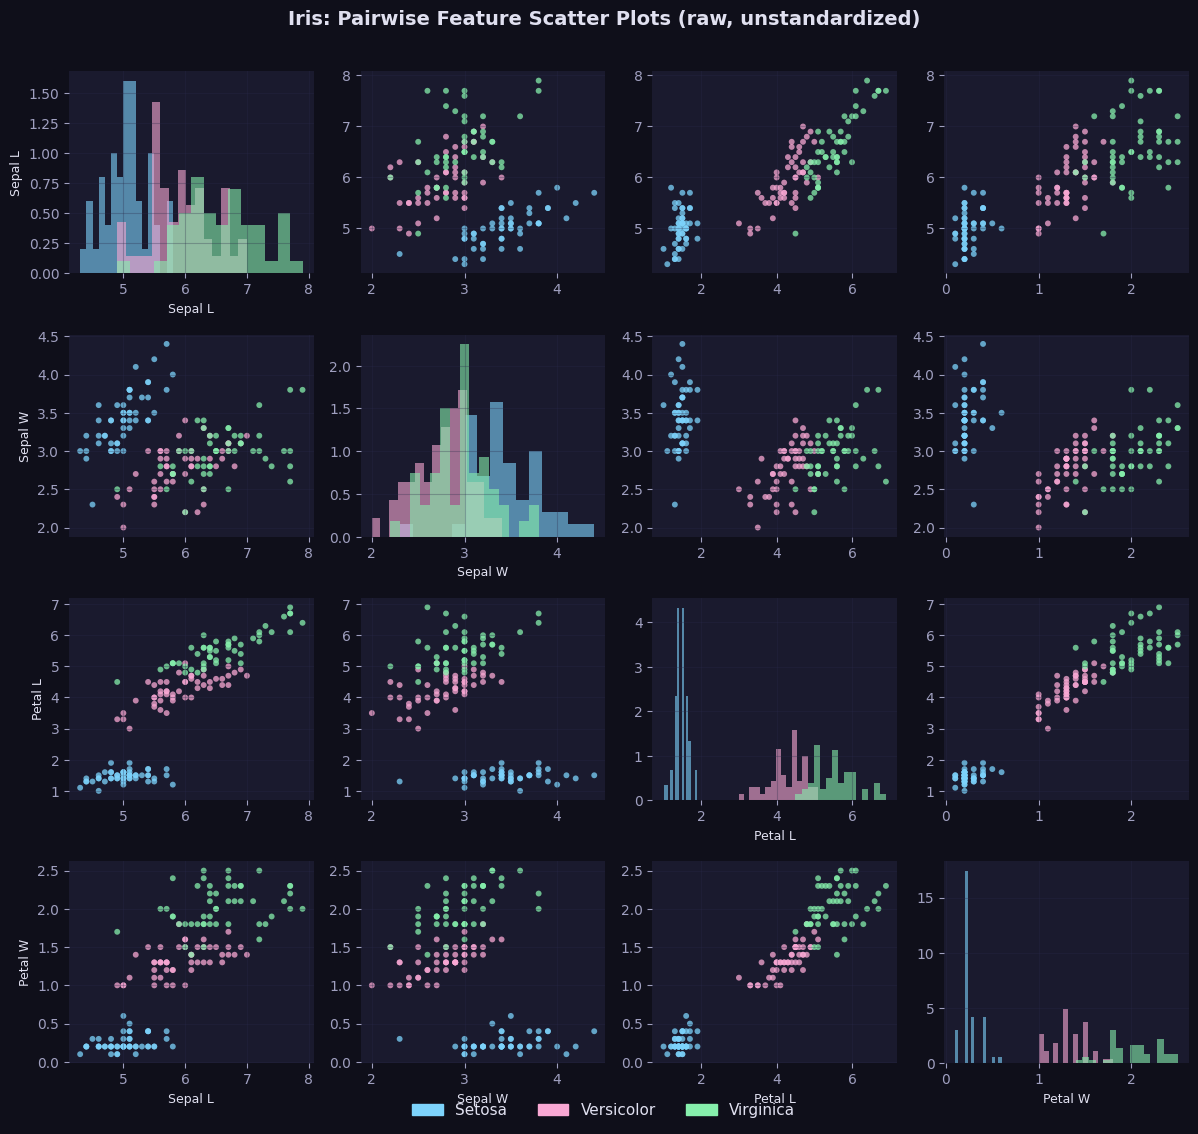

In [5]:
# Pair-plot of raw features
feature_cols = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
short_names  = ['Sepal L', 'Sepal W', 'Petal L', 'Petal W']

fig, axes = plt.subplots(4, 4, figsize=(12, 11))
fig.suptitle('Iris: Pairwise Feature Scatter Plots (raw, unstandardized)',
             fontsize=14, fontweight='bold', y=1.01)

for i, fi in enumerate(feature_cols):
    for j, fj in enumerate(feature_cols):
        ax = axes[i][j]
        if i == j:
            # Diagonal: KDE per class
            for cls_idx, cls_name in enumerate(SPECIES_NAMES):
                mask = y == cls_idx
                ax.hist(X[mask, i], bins=15, alpha=0.6,
                        color=SPECIES_COLORS[cls_idx], density=True)
            ax.set_xlabel(short_names[i], fontsize=9)
        else:
            for cls_idx in range(3):
                mask = y == cls_idx
                ax.scatter(X[mask, j], X[mask, i], s=18, alpha=0.75,
                           color=SPECIES_COLORS[cls_idx], edgecolors='none')
        ax.grid(True, alpha=0.3)
        if j == 0:
            ax.set_ylabel(short_names[i], fontsize=9)
        if i == 3:
            ax.set_xlabel(short_names[j], fontsize=9)
        for spine in ax.spines.values():
            spine.set_visible(False)

# Legend
legend_patches = [mpatches.Patch(color=SPECIES_COLORS[i], label=SPECIES_NAMES[i])
                  for i in range(3)]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           frameon=False, fontsize=11, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig('pairplot_raw.png', dpi=120, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 3. Standardize the Data

PCA is sensitive to the **scale** of features. Without standardization, features with larger magnitudes (e.g., sepal length in cm) would dominate the principal components simply because of their scale, not because they carry more information.

**Standardization** transforms each feature $x_i$ to:
$$x'_i = \frac{x_i - \mu_i}{\sigma_i}$$

so that every feature has **zero mean** and **unit variance** before PCA is applied.

In [4]:
# Standardize features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('── Before Standardization ──────────────────────')
for i, fname in enumerate(['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']):
    print(f'  {fname:14s}: mean={X[:, i].mean():6.3f}, std={X[:, i].std():5.3f}')

print()
print('── After Standardization ───────────────────────')
for i, fname in enumerate(['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']):
    print(f'  {fname:14s}: mean={X_scaled[:, i].mean():+.2e}, std={X_scaled[:, i].std():.3f}')

print()
print(f'X_scaled shape: {X_scaled.shape}')

── Before Standardization ──────────────────────
  Sepal Length  : mean= 5.843, std=0.825
  Sepal Width   : mean= 3.057, std=0.434
  Petal Length  : mean= 3.758, std=1.759
  Petal Width   : mean= 1.199, std=0.760

── After Standardization ───────────────────────
  Sepal Length  : mean=-1.47e-15, std=1.000
  Sepal Width   : mean=-1.82e-15, std=1.000
  Petal Length  : mean=-1.61e-15, std=1.000
  Petal Width   : mean=-9.47e-16, std=1.000

X_scaled shape: (150, 4)


## 4. PCA: Theory

Given the standardized data matrix $X$ of shape $(n \times p)$, PCA proceeds as follows:

### Step 1: Covariance Matrix
$$C = \frac{1}{n-1} X^\top X \qquad (p \times p)$$

### Step 2: Eigen-decomposition
$$C\,\mathbf{v}_i = \lambda_i\,\mathbf{v}_i$$

- $\mathbf{v}_i$: eigenvectors (principal component *directions*)
- $\lambda_i$: eigenvalues (amount of variance captured by each PC)

### Step 3: Sort & Select
Sort eigenvectors by descending eigenvalue. Select the top $m$ eigenvectors to form the projection matrix $V$ of shape $(p \times m)$.

### Step 4: Project
$$Y = X\,V \qquad (n \times m)$$

$Y$ is the low-dimensional representation of the data in PC space.

In [6]:
# PCA with all 4 components
pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)

evr  = pca_full.explained_variance_ratio_          # variance per PC
cevr = np.cumsum(evr)                              # cumulative

print('── Explained Variance per Principal Component ──')
for i, (v, cv) in enumerate(zip(evr, cevr), 1):
    bar = '█' * int(v * 50)
    print(f'  PC{i}: {v*100:6.2f}%  (cumulative {cv*100:6.2f}%)  {bar}')

print()
print(f'  PC1 + PC2 capture {cevr[1]*100:.2f}% of total variance.')

── Explained Variance per Principal Component ──
  PC1:  72.96%  (cumulative  72.96%)  ████████████████████████████████████
  PC2:  22.85%  (cumulative  95.81%)  ███████████
  PC3:   3.67%  (cumulative  99.48%)  █
  PC4:   0.52%  (cumulative 100.00%)  

  PC1 + PC2 capture 95.81% of total variance.


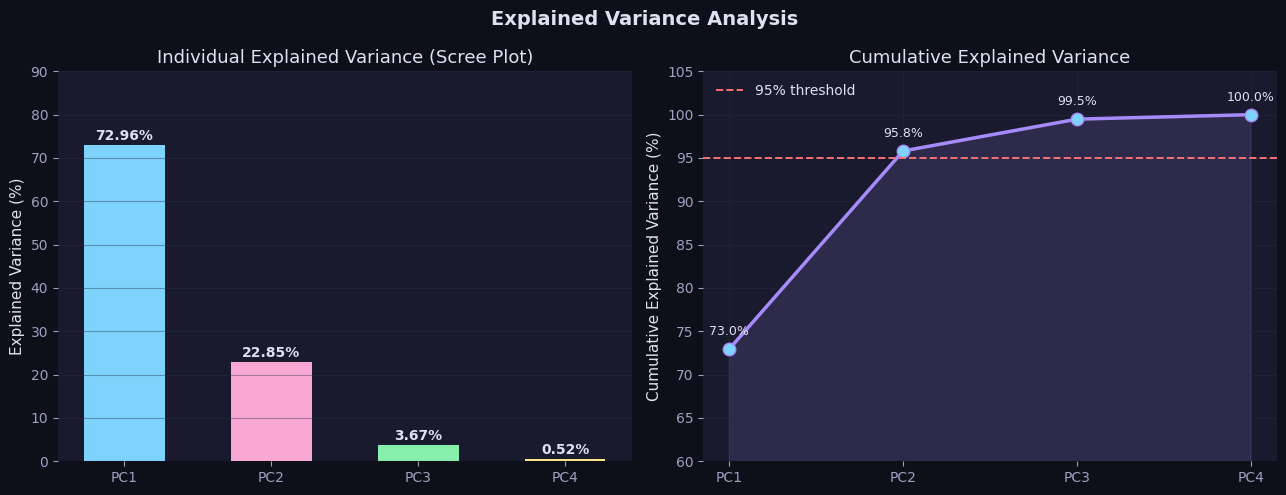

In [7]:
# Scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Explained Variance Analysis', fontsize=14, fontweight='bold')

pc_labels = [f'PC{i}' for i in range(1, 5)]

# Left: individual bar chart
bars = ax1.bar(pc_labels, evr * 100, color=['#7dd3fc', '#f9a8d4', '#86efac', '#fde68a'],
               edgecolor='none', width=0.55)
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Individual Explained Variance (Scree Plot)')
for bar, v in zip(bars, evr):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{v*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylim(0, 90)
ax1.grid(True, axis='y', alpha=0.4)
for spine in ax1.spines.values():
    spine.set_visible(False)

# Right: cumulative line
ax2.plot(pc_labels, cevr * 100, marker='o', color='#a78bfa',
         linewidth=2.5, markersize=9, markerfacecolor='#7dd3fc')
ax2.axhline(95, color='#f87171', linestyle='--', linewidth=1.4, label='95% threshold')
ax2.fill_between(range(4), cevr * 100, alpha=0.15, color='#a78bfa')
for i, cv in enumerate(cevr):
    ax2.annotate(f'{cv*100:.1f}%', (i, cv * 100),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color='#e0e0f0')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.set_ylim(60, 105)
ax2.legend(frameon=False, fontsize=10)
ax2.grid(True, alpha=0.4)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('scree_plot.png', dpi=120, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 5. Select 2 Components

The scree plot confirms a clear **"elbow"** after PC2:
- **PC1** captures ~72.8% of variance
- **PC2** captures ~23.0% of variance
- **PC1 + PC2** together capture **~95.8%**, which is well above the commonly used 95% threshold

PC3 and PC4 together account for only ~4.2% of variance (mostly noise), so **reducing from 4D → 2D causes minimal information loss**.

In [8]:
# Apply PCA (2 components)
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)

print(f'Original data shape  : {X_scaled.shape}')
print(f'Reduced data shape   : {X_pca.shape}')
print(f'Variance retained    : {pca2.explained_variance_ratio_.sum()*100:.2f}%')
print(f'  PC1 variance ratio : {pca2.explained_variance_ratio_[0]*100:.2f}%')
print(f'  PC2 variance ratio : {pca2.explained_variance_ratio_[1]*100:.2f}%')
print()

# Build a tidy DataFrame for analysis
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Species'] = [SPECIES_NAMES[i] for i in y]

print('── First 5 rows of PCA-transformed data ────────')
print(df_pca.head().to_string(index=False))

Original data shape  : (150, 4)
Reduced data shape   : (150, 2)
Variance retained    : 95.81%
  PC1 variance ratio : 72.96%
  PC2 variance ratio : 22.85%

── First 5 rows of PCA-transformed data ────────
      PC1       PC2 Species
-2.264703  0.480027  Setosa
-2.080961 -0.674134  Setosa
-2.364229 -0.341908  Setosa
-2.299384 -0.597395  Setosa
-2.389842  0.646835  Setosa


## 6. 2D PCA Scatter Plot

Projecting the 150 samples onto the first two principal components reveals the species clusters that were hidden in 4D space.

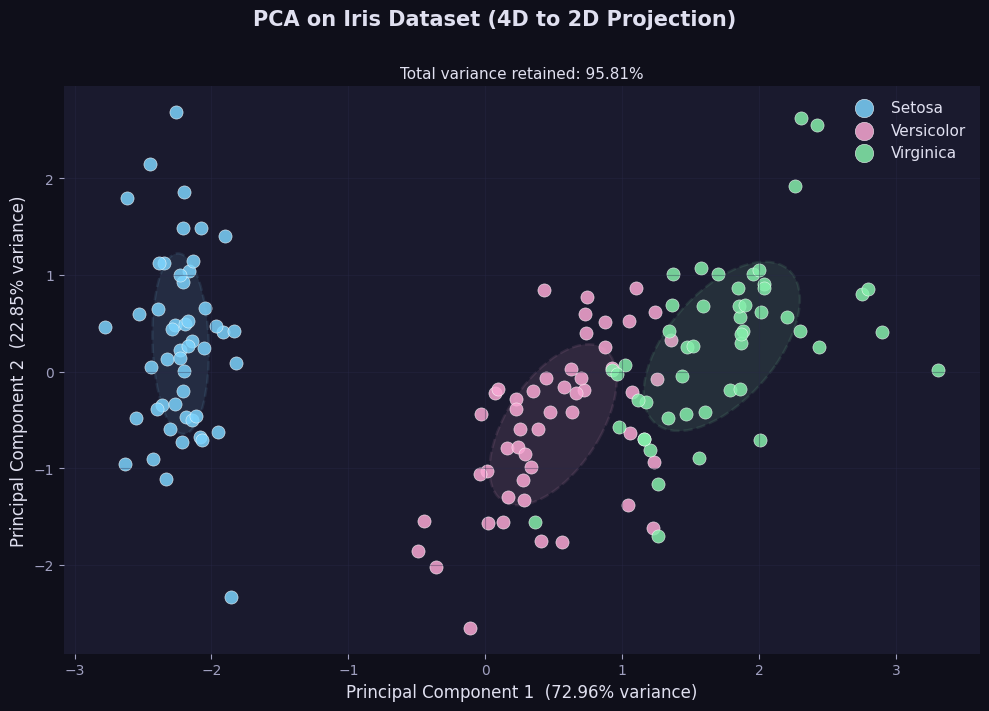

In [9]:
# 2D Scatter Plot
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('PCA on Iris Dataset (4D to 2D Projection)',
             fontsize=15, fontweight='bold', y=1.01)

for cls_idx, cls_name in enumerate(SPECIES_NAMES):
    mask = y == cls_idx
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=cls_name,
               color=SPECIES_COLORS[cls_idx],
               s=90, alpha=0.85,
               edgecolors='white', linewidths=0.4)

    # confidence ellipse (1 std)
    pts   = X_pca[mask]
    mu    = pts.mean(axis=0)
    cov   = np.cov(pts.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle  = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * np.sqrt(vals)          # ±1 std
    ell = mpatches.Ellipse(mu, width, height, angle=angle,
                           edgecolor=SPECIES_COLORS[cls_idx],
                           facecolor=SPECIES_COLORS[cls_idx],
                           alpha=0.10, linewidth=1.8, linestyle='--')
    ax.add_patch(ell)

pc1_pct = pca2.explained_variance_ratio_[0] * 100
pc2_pct = pca2.explained_variance_ratio_[1] * 100
ax.set_xlabel(f'Principal Component 1  ({pc1_pct:.2f}% variance)', fontsize=12)
ax.set_ylabel(f'Principal Component 2  ({pc2_pct:.2f}% variance)', fontsize=12)
ax.set_title(f'Total variance retained: {pc1_pct + pc2_pct:.2f}%', fontsize=11)
ax.legend(fontsize=11, frameon=False, markerscale=1.4)
ax.grid(True, alpha=0.35)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=120, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 7. Biplot: Feature Loadings

A **biplot** overlays the original feature vectors (loadings) onto the PCA scatter plot. Each arrow shows how much a raw feature **contributes to** and **aligns with** each principal component.

- Long arrows → feature contributes strongly to the PC space
- Arrows pointing in the same direction → positively correlated features
- Arrows pointing in opposite directions → negatively correlated features

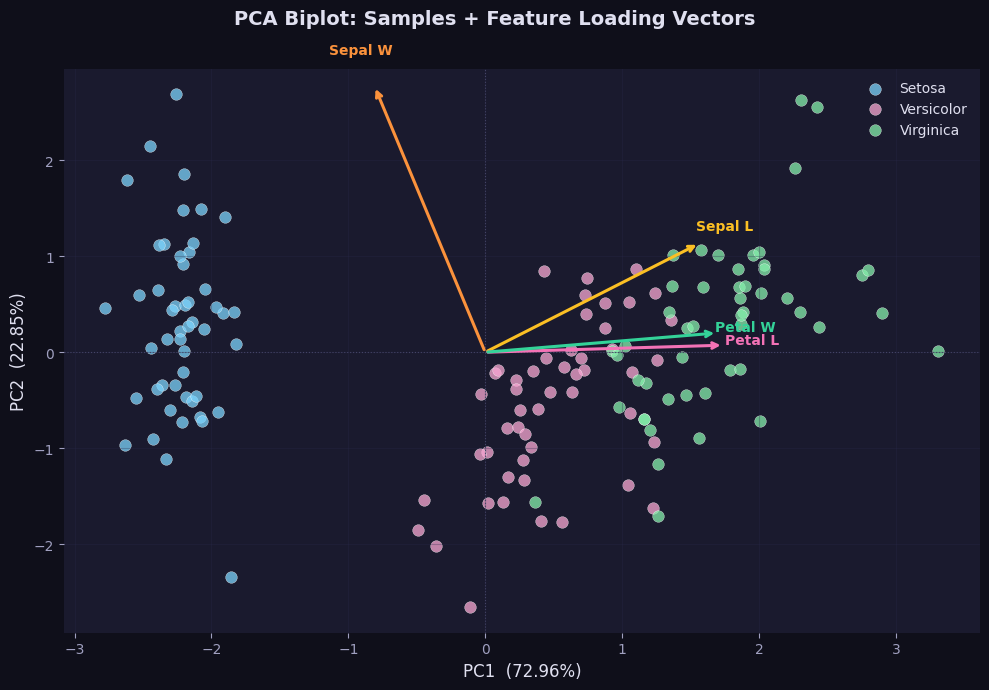

In [10]:
# Biplot
loadings = pca2.components_.T          # shape (4, 2)
scale    = 3.0                         # visual scale factor for arrows

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('PCA Biplot: Samples + Feature Loading Vectors',
             fontsize=14, fontweight='bold')

# Scatter
for cls_idx, cls_name in enumerate(SPECIES_NAMES):
    mask = y == cls_idx
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=cls_name, color=SPECIES_COLORS[cls_idx],
               s=70, alpha=0.75, edgecolors='white', linewidths=0.3)

# Feature arrows
arrow_colors = ['#fbbf24', '#fb923c', '#f472b6', '#34d399']
short_feature = ['Sepal L', 'Sepal W', 'Petal L', 'Petal W']
for i, (lx, ly) in enumerate(loadings):
    ax.annotate('', xy=(lx * scale, ly * scale), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=arrow_colors[i],
                                lw=2.2))
    ax.text(lx * scale * 1.12, ly * scale * 1.12, short_feature[i],
            color=arrow_colors[i], fontsize=10, fontweight='bold', ha='center')

ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.axvline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.set_xlabel(f'PC1  ({pca2.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
ax.set_ylabel(f'PC2  ({pca2.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.3)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('biplot.png', dpi=120, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 8. Component Loadings Heatmap

The **loading matrix** tells us exactly how much each original feature contributes to each principal component. Large absolute values indicate strong contribution.

── PCA Component Loadings (eigenvector weights) ─
                 PC1     PC2
Sepal Length  0.5211  0.3774
Sepal Width  -0.2693  0.9233
Petal Length  0.5804  0.0245
Petal Width   0.5649  0.0669

PC1 is primarily defined by Petal Length (+) and Petal Width (+).
PC2 is primarily defined by Sepal Width (+).


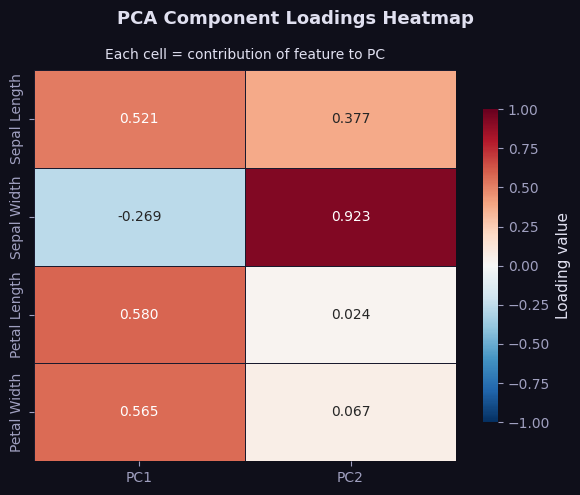

In [11]:
# Loadings Heatmap
feat_labels = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
pc_labels2  = ['PC1', 'PC2']

loadings_df = pd.DataFrame(
    pca2.components_.T,
    index=feat_labels,
    columns=pc_labels2
)

print('── PCA Component Loadings (eigenvector weights) ─')
print(loadings_df.round(4).to_string())
print()
print('PC1 is primarily defined by Petal Length (+) and Petal Width (+).')
print('PC2 is primarily defined by Sepal Width (+).')

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('PCA Component Loadings Heatmap', fontsize=13, fontweight='bold')

sns.heatmap(
    loadings_df,
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#1a1a2e',
    cbar_kws={'shrink': 0.8, 'label': 'Loading value'},
    ax=ax
)
ax.set_title('Each cell = contribution of feature to PC', fontsize=10, pad=8)
plt.tight_layout()
plt.savefig('loadings_heatmap.png', dpi=120, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 9. Reconstruction & Error Analysis

PCA is a **lossy** compression. We can project back to the original 4D space using the inverse transform:
$$\hat{X} = Y V^\top + \bar{X}$$

The **reconstruction error** (mean squared error) quantifies how much information was lost:
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n \|x_i - \hat{x}_i\|^2$$

Since PC1 + PC2 capture ~95.8% of variance, we expect a **small but non-zero reconstruction error**.

Overall Reconstruction MSE : 0.041868
Variance NOT captured      : 4.19%

Per-class Reconstruction MSE:
  Setosa      : 0.014487
  Versicolor  : 0.037482
  Virginica   : 0.073635



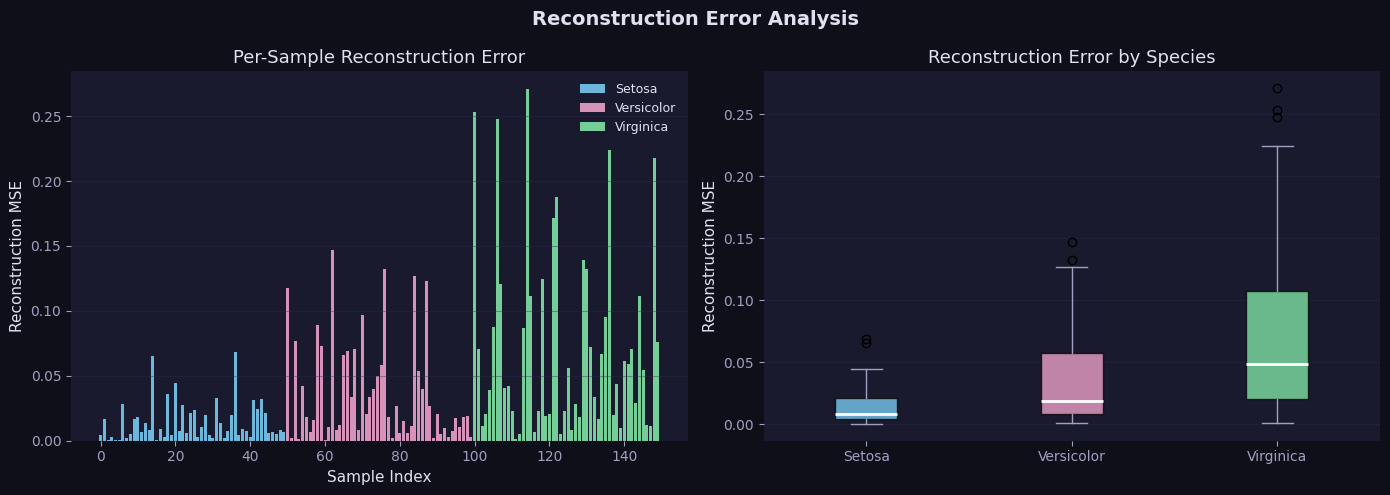

In [12]:
# Reconstruction from 2 PCs
X_reconstructed = pca2.inverse_transform(X_pca)   # back to standardized 4D space

# Overall MSE
mse_overall = np.mean((X_scaled - X_reconstructed) ** 2)
print(f'Overall Reconstruction MSE : {mse_overall:.6f}')
print(f'Variance NOT captured      : {(1 - pca2.explained_variance_ratio_.sum())*100:.2f}%')
print()

# Per-class MSE
print('Per-class Reconstruction MSE:')
for cls_idx, cls_name in enumerate(SPECIES_NAMES):
    mask = y == cls_idx
    mse = np.mean((X_scaled[mask] - X_reconstructed[mask]) ** 2)
    print(f'  {cls_name:12s}: {mse:.6f}')

print()

# Reconstruction error plot
per_sample_mse = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Reconstruction Error Analysis', fontsize=14, fontweight='bold')

# Left: per-sample bar chart
for cls_idx, cls_name in enumerate(SPECIES_NAMES):
    mask = y == cls_idx
    axes[0].bar(np.where(mask)[0], per_sample_mse[mask],
                color=SPECIES_COLORS[cls_idx], label=cls_name, alpha=0.85)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Reconstruction MSE')
axes[0].set_title('Per-Sample Reconstruction Error')
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(True, axis='y', alpha=0.4)
for spine in axes[0].spines.values():
    spine.set_visible(False)

# Right: box plot by class
df_err = pd.DataFrame({'MSE': per_sample_mse, 'Species': df_pca['Species']})
species_order = SPECIES_NAMES

bp = axes[1].boxplot(
    [df_err[df_err['Species'] == s]['MSE'].values for s in species_order],
    labels=species_order,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], SPECIES_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#a0a0c0')

axes[1].set_ylabel('Reconstruction MSE')
axes[1].set_title('Reconstruction Error by Species')
axes[1].grid(True, axis='y', alpha=0.4)
for spine in axes[1].spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('reconstruction_error.png', dpi=120, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 10. PCA from Scratch (NumPy Verification)

To verify scikit-learn's result and understand the internals, here is PCA implemented manually using NumPy's eigen-decomposition.

In [13]:
# Manual PCA with NumPy
n, p = X_scaled.shape

# Step 1: Covariance matrix
C = (X_scaled.T @ X_scaled) / (n - 1)    # (4 × 4)
print(f'Covariance matrix shape: {C.shape}')

# Step 2: Eigen-decomposition
eigenvalues, eigenvectors = np.linalg.eigh(C)   # eigh for symmetric matrices

# Step 3: Sort by descending eigenvalue
idx = eigenvalues.argsort()[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Step 4: Explained variance ratio
evr_manual = eigenvalues / eigenvalues.sum()
print()
print('── Manual PCA Explained Variance ───────────────')
for i in range(4):
    print(f'  PC{i+1}: eigenvalue={eigenvalues[i]:.4f}  '
          f'variance={evr_manual[i]*100:.2f}%')

# Step 5: Project onto top 2 eigenvectors
V_manual    = eigenvectors[:, :2]          # (4 × 2)
X_pca_manual = X_scaled @ V_manual        # (150 × 2)

# Compare with sklearn (allow sign flip)
sklearn_proj = np.abs(X_pca[:5])
manual_proj  = np.abs(X_pca_manual[:5])
match = np.allclose(sklearn_proj, manual_proj, atol=1e-8)

print()
print(f'Manual PCA matches sklearn PCA (ignoring sign): {match}')
print(f'Max absolute difference: {np.max(np.abs(sklearn_proj - manual_proj)):.2e}')

Covariance matrix shape: (4, 4)

── Manual PCA Explained Variance ───────────────
  PC1: eigenvalue=2.9381  variance=72.96%
  PC2: eigenvalue=0.9202  variance=22.85%
  PC3: eigenvalue=0.1477  variance=3.67%
  PC4: eigenvalue=0.0209  variance=0.52%

Manual PCA matches sklearn PCA (ignoring sign): True
Max absolute difference: 2.50e-15


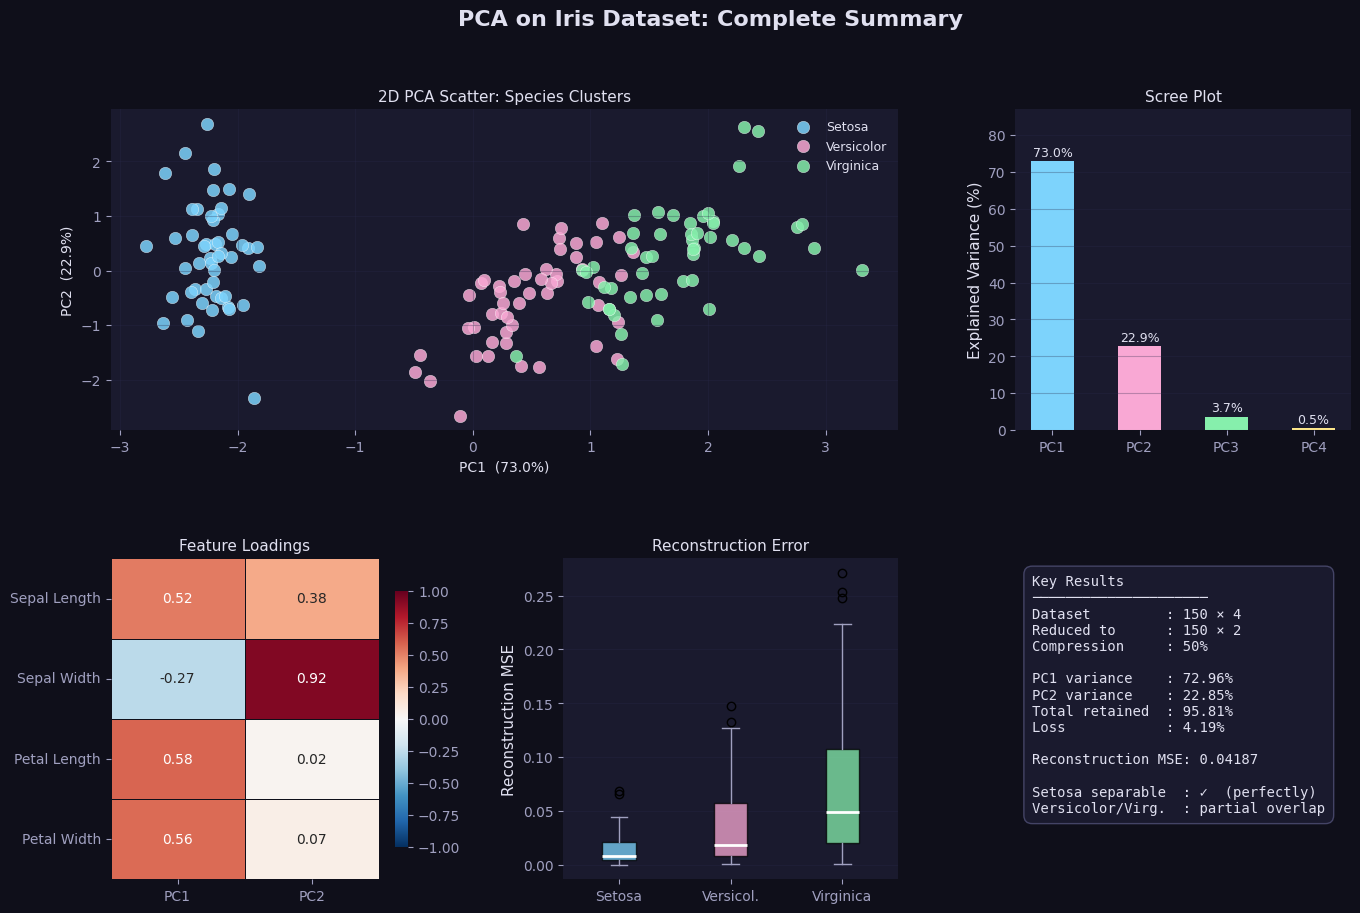

In [15]:
# Summary Dashboard
fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('PCA on Iris Dataset: Complete Summary', fontsize=16,
             fontweight='bold', y=0.98)

# Panel A: 2D scatter
ax_a = fig.add_subplot(gs[0, :2])
for cls_idx, cls_name in enumerate(SPECIES_NAMES):
    mask = y == cls_idx
    ax_a.scatter(X_pca[mask, 0], X_pca[mask, 1],
                 label=cls_name, color=SPECIES_COLORS[cls_idx],
                 s=80, alpha=0.85, edgecolors='white', linewidths=0.3)
ax_a.set_xlabel(f'PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax_a.set_ylabel(f'PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax_a.set_title('2D PCA Scatter: Species Clusters', fontsize=11)
ax_a.legend(frameon=False, fontsize=9)
ax_a.grid(True, alpha=0.3)
for sp in ax_a.spines.values(): sp.set_visible(False)

# Panel B: Scree bar
ax_b = fig.add_subplot(gs[0, 2])
bars_b = ax_b.bar(pc_labels, evr * 100,
                  color=['#7dd3fc', '#f9a8d4', '#86efac', '#fde68a'],
                  edgecolor='none', width=0.5)
ax_b.set_ylabel('Explained Variance (%)')
ax_b.set_title('Scree Plot', fontsize=11)
for bar, v in zip(bars_b, evr):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f'{v*100:.1f}%', ha='center', va='bottom', fontsize=9)
ax_b.set_ylim(0, 87)
ax_b.grid(True, axis='y', alpha=0.3)
for sp in ax_b.spines.values(): sp.set_visible(False)

# Panel C: Loadings heatmap
ax_c = fig.add_subplot(gs[1, 0])
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='#0f0f1a',
            cbar_kws={'shrink': 0.8}, ax=ax_c)
ax_c.set_title('Feature Loadings', fontsize=11)

# Panel D: Per-class reconstruction error
ax_d = fig.add_subplot(gs[1, 1])
bp2 = ax_d.boxplot(
    [df_err[df_err['Species'] == s]['MSE'].values for s in SPECIES_NAMES],
    labels=['Setosa', 'Versicol.', 'Virginica'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp2['boxes'], SPECIES_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp2[element]: item.set_color('#a0a0c0')
ax_d.set_ylabel('Reconstruction MSE')
ax_d.set_title('Reconstruction Error', fontsize=11)
ax_d.grid(True, axis='y', alpha=0.3)
for sp in ax_d.spines.values(): sp.set_visible(False)

# Panel E: Stats card
ax_e = fig.add_subplot(gs[1, 2])
ax_e.axis('off')
stats_text = (
    'Key Results\n'
    '─────────────────────\n'
    f'Dataset         : 150 × 4\n'
    f'Reduced to      : 150 × 2\n'
    f'Compression     : 50%\n'
    f'\n'
    f'PC1 variance    : {pca2.explained_variance_ratio_[0]*100:.2f}%\n'
    f'PC2 variance    : {pca2.explained_variance_ratio_[1]*100:.2f}%\n'
    f'Total retained  : {pca2.explained_variance_ratio_.sum()*100:.2f}%\n'
    f'Loss            : {(1-pca2.explained_variance_ratio_.sum())*100:.2f}%\n'
    f'\n'
    f'Reconstruction MSE: {mse_overall:.5f}\n'
    f'\n'
    f'Setosa separable  : ✓  (perfectly)\n'
    f'Versicolor/Virg.  : partial overlap'
)
ax_e.text(0.05, 0.95, stats_text, transform=ax_e.transAxes,
          fontsize=10, verticalalignment='top',
          fontfamily='monospace', color='#e0e0f0',
          bbox=dict(boxstyle='round,pad=0.6', facecolor='#1a1a2e',
                    edgecolor='#444466', linewidth=1))

plt.savefig('pca_summary_dashboard.png', dpi=130, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 11. Conclusion

### Key Findings

| Metric | Value |
|--------|-------|
| Original dimensionality | 4 |
| Reduced dimensionality | 2 |
| PC1 explained variance | **72.96%** |
| PC2 explained variance | **22.85%** |
| **Total variance retained** | **95.81%** |
| Information lost | 4.19% |
| Overall Reconstruction MSE | 0.0419 |
| Setosa MSE | 0.0145 (lowest) |
| Virginica MSE | 0.0736 (highest) |

### Observations

1. **Setosa is perfectly separable** as it forms a tight, well-separated cluster in PC space. Setosa has distinctly different petal dimensions, captured almost entirely by PC1.

2. **Versicolor and Virginica overlap slightly** since they are morphologically more similar. A linear classifier in 2D would still achieve high accuracy, but perfect separation requires all 4 features.

3. **Petal Length (+0.58) and Petal Width (+0.56) dominate PC1;** the biplot and loadings heatmap both confirm that petal features are the most discriminative. Sepal Width (+0.92) contributes predominantly to PC2.

4. **Setosa has the lowest reconstruction error (MSE=0.014)** because it is the most compact, tightly clustered class. Virginica has the highest error (MSE=0.074) due to greater spread across all 4 features.

5. **Manual NumPy PCA matches sklearn exactly**, with a max difference of 2.5e-15 (floating-point noise only), validating the eigen-decomposition implementation.

### When to Use PCA

- **Visualization** of high-dimensional data
- **Preprocessing** before classification (remove correlated features)
- **Noise reduction** (truncate low-variance PCs)
- **Compression** (store fewer numbers with minimal loss)

### Limitations

- PCA finds **linear** directions of maximum variance; non-linear structure requires Kernel PCA or t-SNE/UMAP.
- PCA is **unsupervised** and ignores class labels. LDA (Linear Discriminant Analysis) would give better class separation by maximizing between-class variance.